#import

In [ ]:
!pip install -q numpy pandas scikit-learn tensorflow

In [ ]:
# ----------------- Standard Library -----------------
import os
import math
import json
import random
from typing import Dict, Tuple

# ----------------- Third-party Libraries -----------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- TensorFlow / Keras -----------------
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

# ----------------- Sklearn -----------------
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive



# 🟦 Case 1 — Image Only

**Goal:** Establish a true baseline using only raw images.  
This tells us how well EfficientNetV2B0 performs without any extra signals.

- No metadata  
- No augmentation  
- No oversampling  
- Using ImageNet weights  
- Full 2-stage fine-tuning  

## 1st RUN

In [ ]:


# -------------------------------------------------------------
# CONFIG
# -------------------------------------------------------------
CONFIG = {
    # "IMG_DIRS": [
    #     r"/content/drive/MyDrive/ham10000/HAM10000_images_part_1",
    #     r"/content/drive/MyDrive/ham10000/HAM10000_images_part_2",
    # ],
    "IMG_DIRS": [
        r"/content/drive/MyDrive/project comvis/HAM10000_images_part_1",
        r"/content/drive/MyDrive/project comvis/HAM10000_images_part_2",
    ],
    #"METADATA_CSV": r"/content/drive/MyDrive/ham10000/HAM10000_metadata.csv",
    "METADATA_CSV": r"/content/drive/MyDrive/project comvis/HAM10000_metadata.csv",
    "IMG_SIZE": 224,
    "BATCH": 32,
    "EPOCHS": 40,
    "MIXED_PRECISION": True,
    "OUTPUT_DIR": r"/content/drive/MyDrive/project comvis/outputs_case1",
    "SEED": 42,
}

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

if CONFIG["MIXED_PRECISION"]:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

# -------------------------------------------------------------
# LOAD IMAGE PATHS
# -------------------------------------------------------------
def collect_image_paths(img_dirs):
    paths = []
    for d in img_dirs:
        if os.path.isdir(d):
            for fn in os.listdir(d):
                if fn.lower().endswith((".jpg", ".jpeg", ".png")):
                    paths.append(os.path.join(d, fn))
    return paths

all_paths = collect_image_paths(CONFIG["IMG_DIRS"])

name2path = {}
for p in all_paths:
    name = os.path.splitext(os.path.basename(p))[0]
    name2path[name] = p

# -------------------------------------------------------------
# LOAD METADATA (LABELS ONLY)
# -------------------------------------------------------------
md = pd.read_csv(CONFIG["METADATA_CSV"])

CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

md = md[md["dx"].isin(CLASSES)].copy()
md["label_idx"] = md["dx"].map(CLASS2IDX).astype(int)

md["image_path"] = md["image_id"].map(name2path)
md = md[~md["image_path"].isna()].copy()

print("Total images:", len(md))

# -------------------------------------------------------------
# STRATIFIED SPLIT 80/10/10
# -------------------------------------------------------------
train_df, temp_df = train_test_split(
    md, test_size=0.2, stratify=md["label_idx"], random_state=CONFIG["SEED"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label_idx"], random_state=CONFIG["SEED"]
)

print(f"Split → train:{len(train_df)}, val:{len(val_df)}, test:{len(test_df)}")

# -------------------------------------------------------------
# BUILD NUMPY ARRAYS
# -------------------------------------------------------------
def build_np_arrays(df):
    paths = df["image_path"].tolist()
    labels = df["label_idx"].astype(np.int32).values
    return np.array(paths), labels

train_paths, train_y = build_np_arrays(train_df)
val_paths,   val_y   = build_np_arrays(val_df)
test_paths,  test_y  = build_np_arrays(test_df)

# -------------------------------------------------------------
# TF.DATA PIPELINE (NO AUGMENTATION)
# -------------------------------------------------------------
IMG_SIZE = CONFIG["IMG_SIZE"]

@tf.function
def preprocess_image(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    return img

try:
    from tensorflow.keras.applications import efficientnet_v2
    eff_pre = efficientnet_v2.preprocess_input
except:
    eff_pre = lambda x: x / 255.0

def load_and_preprocess(path, label):
    img = preprocess_image(path)
    img = eff_pre(img)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_y))
train_ds = train_ds.shuffle(2000).map(load_and_preprocess).batch(CONFIG["BATCH"]).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_y))
val_ds = val_ds.map(load_and_preprocess).batch(CONFIG["BATCH"]).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_y))
test_ds = test_ds.map(load_and_preprocess).batch(CONFIG["BATCH"]).prefetch(tf.data.AUTOTUNE)

# -------------------------------------------------------------
# MODEL (IMAGE-ONLY)
# -------------------------------------------------------------
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

img_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")

base = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_tensor=img_in,
    pooling="avg"
)

# Stage 1: Freeze
for layer in base.layers:
    layer.trainable = False

h = layers.Dropout(0.3)(base.output)
out = layers.Dense(len(CLASSES), activation="softmax", dtype="float32")(h)

model = Model(inputs=img_in, outputs=out)

# Optimizers (เหมือน FT3)
try:
    from tensorflow.keras.optimizers import AdamW
except:
    from tensorflow.keras.optimizers.experimental import AdamW

LR_HEAD = 1e-4
LR_FINETUNE = 5e-6
WEIGHT_DECAY = 1e-6

optimizer_head     = AdamW(LR_HEAD, weight_decay=WEIGHT_DECAY)
optimizer_finetune = AdamW(LR_FINETUNE, weight_decay=WEIGHT_DECAY)

model.compile(
    optimizer=optimizer_head,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------------------------------------
# STAGE 1 — TRAIN HEAD
# -------------------------------------------------------------
steps_per_epoch = math.ceil(len(train_df) / CONFIG["BATCH"])

callbacks_head = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(patience=3, factor=0.2, monitor="val_loss", min_lr=1e-6),
    ModelCheckpoint(os.path.join(CONFIG["OUTPUT_DIR"], "case1_head.keras"),
                    monitor="val_accuracy", save_best_only=True)
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks_head,
    verbose=1
)

# -------------------------------------------------------------
# STAGE 2 — UNFREEZE BACKBONE
# -------------------------------------------------------------
trainable_count = 0
for layer in base.layers:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
        trainable_count += 1

model.compile(
    optimizer=optimizer_finetune,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_ft = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(patience=4, factor=0.2, monitor="val_loss", min_lr=1e-7),
    ModelCheckpoint(os.path.join(CONFIG["OUTPUT_DIR"], "case1_finetune.keras"),
                    monitor="val_accuracy", save_best_only=True)
]

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks_ft,
    verbose=1
)

# -------------------------------------------------------------
# EVALUATION
# -------------------------------------------------------------
print("\n==================== TEST SET ====================")
results = model.evaluate(test_ds, verbose=1)
print(dict(zip(model.metrics_names, results)))


Total images: 10015
Split → train:8012, val:1001, test:1002
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 877s 3s/step - accuracy: 0.6428 - loss: 1.2643 - val_accuracy: 0.6673 - val_loss: 1.0123 - learning_rate: 1.0000e-04
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 75s 299ms/step - accuracy: 0.6751 - loss: 1.0008 - val_accuracy: 0.6743 - val_loss: 0.9384 - learning_rate: 1.0000e-04
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 70s 279ms/step - accuracy: 0.6864 - loss: 0.9252 - val_accuracy: 0.6823 - val_loss: 0.8928 - learning_rate: 1.0000e-04
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 70s 280ms/step - accuracy: 0.6878 - loss: 0.8903 - val_accuracy: 0.6883 - val_loss: 0.8629 - learning_rate: 1.0000e-04
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 83s 284ms/step - accuracy: 0.6988 - loss: 0.8562 - val_accuracy: 0.6923 - val_loss: 0.8398 - learning_rate: 1.0000e-04
Epoch 1/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 319s 792ms/step - accuracy: 0.7121 - loss: 0.7939 - val_accur


================= TRAINING SUMMARY =================
Epochs run          : 35
Best Val Accuracy   : 0.8452 (Epoch 27)
Final Train Accuracy: 0.9126
Final Val Accuracy  : 0.8442



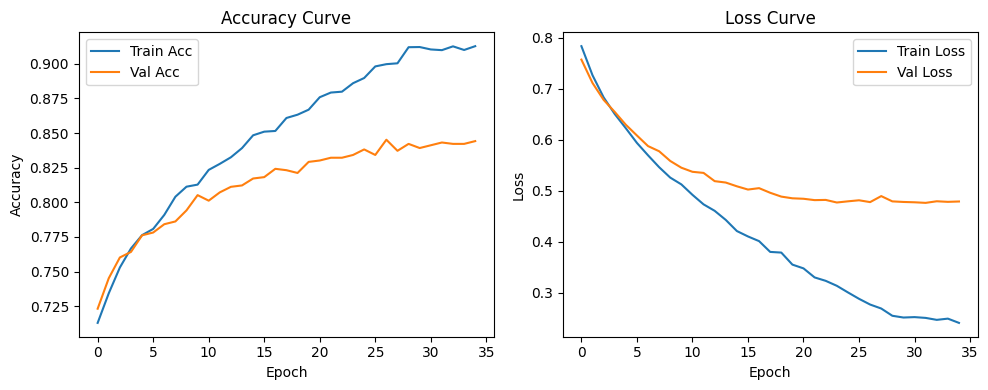


================= TEST EVALUATION ==================
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.8591 - loss: 0.3831
Test Accuracy : 0.8553
Test Loss     : 0.3944

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step


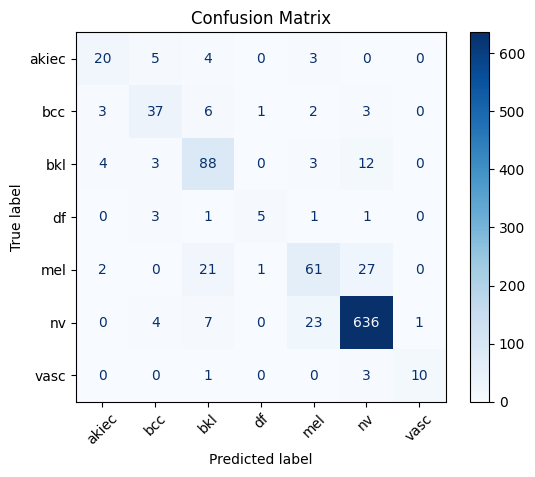


================= CLASSIFICATION REPORT =================


In [ ]:
# 1) TRAINING SUMMARY
# -------------------------------------------------------------
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt

hist = history_ft.history  # final stage history

epochs_ran     = len(hist["accuracy"])
best_val_acc   = max(hist["val_accuracy"])
best_epoch     = np.argmax(hist["val_accuracy"]) + 1
final_train_acc = hist["accuracy"][-1]
final_val_acc   = hist["val_accuracy"][-1]

print("\n================= TRAINING SUMMARY =================")
print(f"Epochs run          : {epochs_ran}")
print(f"Best Val Accuracy   : {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Val Accuracy  : {final_val_acc:.4f}")
print("====================================================\n")


# -------------------------------------------------------------
# 2) LEARNING CURVES
# -------------------------------------------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(hist["accuracy"], label="Train Acc")
plt.plot(hist["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist["loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# -------------------------------------------------------------
# 3) TEST EVALUATION
# -------------------------------------------------------------
print("\n================= TEST EVALUATION ==================")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print("====================================================\n")


# -------------------------------------------------------------
# 4) PREDICT
# -------------------------------------------------------------
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)


# -------------------------------------------------------------
# 5) CONFUSION MATRIX
# -------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# -------------------------------------------------------------
# 6) CLASSIFICATION REPORT
# -------------------------------------------------------------
print("\n================= CLASSIFICATION REPORT =================")

In [ ]:
# 1) TRAINING SUMMARY
# -------------------------------------------------------------
hist = history_ft.history  # final stage history

epochs_ran     = len(hist["accuracy"])
best_val_acc   = max(hist["val_accuracy"])
best_epoch     = np.argmax(hist["val_accuracy"]) + 1
final_train_acc = hist["accuracy"][-1]
final_val_acc   = hist["val_accuracy"][-1]

print("\n================= TRAINING SUMMARY =================")
print(f"Epochs run          : {epochs_ran}")
print(f"Best Val Accuracy   : {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Val Accuracy  : {final_val_acc:.4f}")
print("====================================================\n")


# -------------------------------------------------------------
# 2) LEARNING CURVES
# -------------------------------------------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(hist["accuracy"], label="Train Acc")
plt.plot(hist["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist["loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# -------------------------------------------------------------
# 3) TEST EVALUATION
# -------------------------------------------------------------
print("\n================= TEST EVALUATION ==================")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print("====================================================\n")


# -------------------------------------------------------------
# 4) PREDICT
# -------------------------------------------------------------
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)


# -------------------------------------------------------------
# 5) CONFUSION MATRIX
# -------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# -------------------------------------------------------------
# 6) CLASSIFICATION REPORT
# -------------------------------------------------------------
print("\n================= CLASSIFICATION REPORT =================")
print(classification_report(y_true, y_pred, target_names=CLASSES))
print("=========================================================\n")


# -------------------------------------------------------------
# 7) ADVANCED METRICS: Precision, Recall, F1, AUC
# -------------------------------------------------------------
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro    = recall_score(y_true, y_pred, average="macro")
f1_macro        = f1_score(y_true, y_pred, average="macro")
f1_weighted     = f1_score(y_true, y_pred, average="weighted")

print("\n================= ADVANCED METRICS =================")
print(f"Macro Precision : {precision_macro:.4f}")
print(f"Macro Recall    : {recall_macro:.4f}")
print(f"Macro F1-score  : {f1_macro:.4f}")
print(f"Weighted F1     : {f1_weighted:.4f}")

# macro ROC-AUC (One-vs-Rest)
try:
    y_true_bin = label_binarize(y_true, classes=range(len(CLASSES)))
    auc_macro = roc_auc_score(y_true_bin, y_pred_prob, average="macro")
    print(f"ROC-AUC (macro, OvR): {auc_macro:.4f}")
except Exception as e:
    print("ROC-AUC skipped:", e)

print("====================================================\n")


# -------------------------------------------------------------
# 8) ROC CURVES (Per Class)
# -------------------------------------------------------------
try:
    fpr = {}; tpr = {}; roc_auc = {}
    y_bin = label_binarize(y_true, classes=range(len(CLASSES)))

    for i in range(len(CLASSES)):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(7,6))
    colors = cycle(["red","green","blue","orange","purple","brown","cyan"])

    for i, color in zip(range(len(CLASSES)), colors):
        plt.plot(fpr[i], tpr[i], lw=2, color=color,
                 label=f"{CLASSES[i]} (AUC={roc_auc[i]:.3f})")

    plt.plot([0,1], [0,1], "k--")
    plt.title("ROC Curves (Per Class)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

except Exception as e:
    print("ROC curve plotting skipped:", e)

✅ Classification Report

| Class | Precision | Recall | F1-score | Support |
| ----- | --------- | ------ | -------- | ------- |
| akiec | 0.69      | 0.62   | 0.66     | 32      |
| bcc   | 0.71      | 0.71   | 0.71     | 52      |
| bkl   | 0.69      | 0.80   | 0.74     | 110     |
| df    | 0.71      | 0.45   | 0.56     | 11      |
| mel   | 0.66      | 0.54   | 0.60     | 112     |
| nv    | 0.95      | 0.95   | 0.94     | 671     |
| vasc  | 0.91      | 0.71   | 0.80     | 14      |


| Metric              | Value  |
| ------------------- | ------ |
| **Accuracy**        | 0.855  |
| **Macro Precision** | 0.7572 |
| **Macro Recall**    | 0.6854 |
| **Macro F1**        | 0.7139 |
| **Weighted F1**     | 0.8524 |


## 2nd Run

In [ ]:


# -------------------------------------------------------------
# CONFIG
# -------------------------------------------------------------
CONFIG = {
    # "IMG_DIRS": [
    #     r"/content/drive/MyDrive/ham10000/HAM10000_images_part_1",
    #     r"/content/drive/MyDrive/ham10000/HAM10000_images_part_2",
    # ],
    "IMG_DIRS": [
        r"/content/drive/MyDrive/project comvis/HAM10000_images_part_1",
        r"/content/drive/MyDrive/project comvis/HAM10000_images_part_2",
    ],
    #"METADATA_CSV": r"/content/drive/MyDrive/ham10000/HAM10000_metadata.csv",
    "METADATA_CSV": r"/content/drive/MyDrive/project comvis/HAM10000_metadata.csv",
    "IMG_SIZE": 224,
    "BATCH": 32,
    "EPOCHS": 40,
    "MIXED_PRECISION": True,
    "OUTPUT_DIR": r"/content/drive/MyDrive/project comvis/outputs_case1_2nd",
    "SEED": 42,
}

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

if CONFIG["MIXED_PRECISION"]:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

# -------------------------------------------------------------
# LOAD IMAGE PATHS
# -------------------------------------------------------------
def collect_image_paths(img_dirs):
    paths = []
    for d in img_dirs:
        if os.path.isdir(d):
            for fn in os.listdir(d):
                if fn.lower().endswith((".jpg", ".jpeg", ".png")):
                    paths.append(os.path.join(d, fn))
    return paths

all_paths = collect_image_paths(CONFIG["IMG_DIRS"])

name2path = {}
for p in all_paths:
    name = os.path.splitext(os.path.basename(p))[0]
    name2path[name] = p

# -------------------------------------------------------------
# LOAD METADATA (LABELS ONLY)
# -------------------------------------------------------------
md = pd.read_csv(CONFIG["METADATA_CSV"])

CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

md = md[md["dx"].isin(CLASSES)].copy()
md["label_idx"] = md["dx"].map(CLASS2IDX).astype(int)

md["image_path"] = md["image_id"].map(name2path)
md = md[~md["image_path"].isna()].copy()

print("Total images:", len(md))

# -------------------------------------------------------------
# STRATIFIED SPLIT 80/10/10
# -------------------------------------------------------------
train_df, temp_df = train_test_split(
    md, test_size=0.2, stratify=md["label_idx"], random_state=CONFIG["SEED"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label_idx"], random_state=CONFIG["SEED"]
)

print(f"Split → train:{len(train_df)}, val:{len(val_df)}, test:{len(test_df)}")

# -------------------------------------------------------------
# BUILD NUMPY ARRAYS
# -------------------------------------------------------------
def build_np_arrays(df):
    paths = df["image_path"].tolist()
    labels = df["label_idx"].astype(np.int32).values
    return np.array(paths), labels

train_paths, train_y = build_np_arrays(train_df)
val_paths,   val_y   = build_np_arrays(val_df)
test_paths,  test_y  = build_np_arrays(test_df)

# -------------------------------------------------------------
# TF.DATA PIPELINE (NO AUGMENTATION)
# -------------------------------------------------------------
IMG_SIZE = CONFIG["IMG_SIZE"]

@tf.function
def preprocess_image(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    return img

try:
    from tensorflow.keras.applications import efficientnet_v2
    eff_pre = efficientnet_v2.preprocess_input
except:
    eff_pre = lambda x: x / 255.0

def load_and_preprocess(path, label):
    img = preprocess_image(path)
    img = eff_pre(img)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_y))
train_ds = train_ds.shuffle(2000).map(load_and_preprocess).batch(CONFIG["BATCH"]).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_y))
val_ds = val_ds.map(load_and_preprocess).batch(CONFIG["BATCH"]).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_y))
test_ds = test_ds.map(load_and_preprocess).batch(CONFIG["BATCH"]).prefetch(tf.data.AUTOTUNE)

# -------------------------------------------------------------
# MODEL (IMAGE-ONLY)
# -------------------------------------------------------------
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

img_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")

base = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_tensor=img_in,
    pooling="avg"
)

# Stage 1: Freeze
for layer in base.layers:
    layer.trainable = False

h = layers.Dropout(0.3)(base.output)
out = layers.Dense(len(CLASSES), activation="softmax", dtype="float32")(h)

model = Model(inputs=img_in, outputs=out)

# Optimizers (เหมือน FT3)
try:
    from tensorflow.keras.optimizers import AdamW
except:
    from tensorflow.keras.optimizers.experimental import AdamW

LR_HEAD = 1e-4
LR_FINETUNE = 5e-6
WEIGHT_DECAY = 1e-6

optimizer_head     = AdamW(LR_HEAD, weight_decay=WEIGHT_DECAY)
optimizer_finetune = AdamW(LR_FINETUNE, weight_decay=WEIGHT_DECAY)

model.compile(
    optimizer=optimizer_head,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------------------------------------
# STAGE 1 — TRAIN HEAD
# -------------------------------------------------------------
steps_per_epoch = math.ceil(len(train_df) / CONFIG["BATCH"])

callbacks_head = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(patience=3, factor=0.2, monitor="val_loss", min_lr=1e-6),
    ModelCheckpoint(os.path.join(CONFIG["OUTPUT_DIR"], "case1_head.keras"),
                    monitor="val_accuracy", save_best_only=True)
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks_head,
    verbose=1
)

# -------------------------------------------------------------
# STAGE 2 — UNFREEZE BACKBONE
# -------------------------------------------------------------
trainable_count = 0
for layer in base.layers:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
        trainable_count += 1

model.compile(
    optimizer=optimizer_finetune,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_ft = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(patience=4, factor=0.2, monitor="val_loss", min_lr=1e-7),
    ModelCheckpoint(os.path.join(CONFIG["OUTPUT_DIR"], "case1_finetune.keras"),
                    monitor="val_accuracy", save_best_only=True)
]

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks_ft,
    verbose=1
)

# -------------------------------------------------------------
# EVALUATION
# -------------------------------------------------------------
print("\n==================== TEST SET ====================")
results = model.evaluate(test_ds, verbose=1)
print(dict(zip(model.metrics_names, results)))


Total images: 10015
Split → train:8012, val:1001, test:1002
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 2069s 8s/step - accuracy: 0.4491 - loss: 1.5663 - val_accuracy: 0.6683 - val_loss: 1.0270 - learning_rate: 1.0000e-04
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 77s 306ms/step - accuracy: 0.6688 - loss: 1.0285 - val_accuracy: 0.6703 - val_loss: 0.9629 - learning_rate: 1.0000e-04
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 72s 289ms/step - accuracy: 0.6779 - loss: 0.9639 - val_accuracy: 0.6793 - val_loss: 0.9194 - learning_rate: 1.0000e-04
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 70s 281ms/step - accuracy: 0.6873 - loss: 0.9027 - val_accuracy: 0.6853 - val_loss: 0.8872 - learning_rate: 1.0000e-04
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 83s 287ms/step - accuracy: 0.6962 - loss: 0.8700 - val_accuracy: 0.6903 - val_loss: 0.8618 - learning_rate: 1.0000e-04
Epoch 1/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 332s 831ms/step - accuracy: 0.7055 - loss: 0.8332 - val_accu


================= TRAINING SUMMARY =================
Epochs run          : 36
Best Val Accuracy   : 0.8511 (Epoch 28)
Final Train Accuracy: 0.9151
Final Val Accuracy  : 0.8501



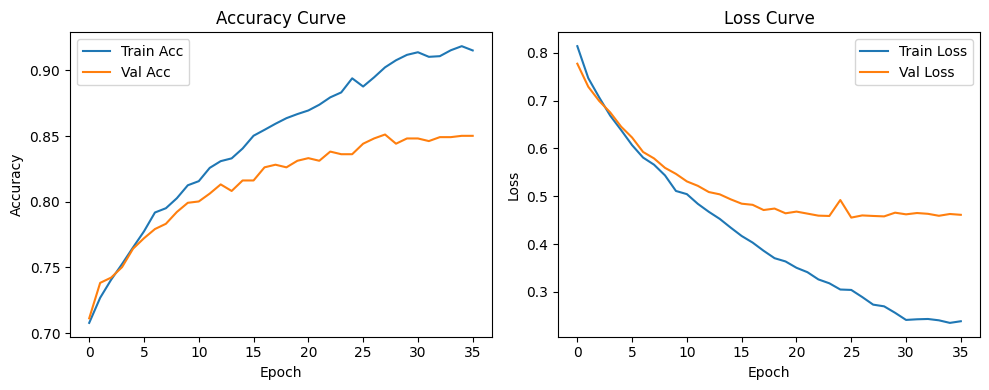


================= TEST EVALUATION ==================
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.8580 - loss: 0.3826
Test Accuracy : 0.8623
Test Loss     : 0.3932

32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 747ms/step


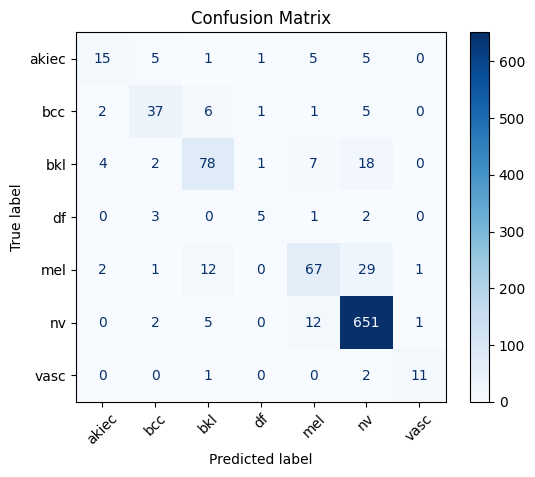


================= CLASSIFICATION REPORT =================
              precision    recall  f1-score   support

       akiec       0.65      0.47      0.55        32
         bcc       0.74      0.71      0.73        52
         bkl       0.76      0.71      0.73       110
          df       0.62      0.45      0.53        11
         mel       0.72      0.60      0.65       112
          nv       0.91      0.97      0.94       671
        vasc       0.85      0.79      0.81        14

    accuracy                           0.86      1002
   macro avg       0.75      0.67      0.71      1002
weighted avg       0.85      0.86      0.86      1002



================= ADVANCED METRICS =================
Macro Precision : 0.7508
Macro Recall    : 0.6711
Macro F1-score  : 0.7057
Weighted F1     : 0.8561
ROC-AUC (macro, OvR): 0.9747



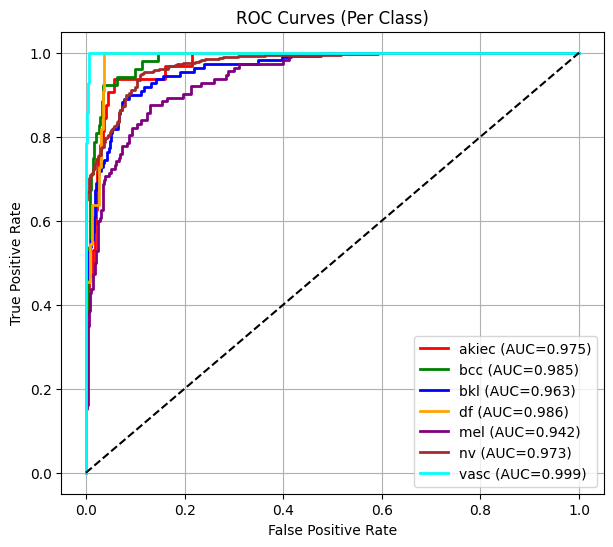

In [ ]:
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt

# 1) TRAINING SUMMARY
# -------------------------------------------------------------
hist = history_ft.history  # final stage history

epochs_ran     = len(hist["accuracy"])
best_val_acc   = max(hist["val_accuracy"])
best_epoch     = np.argmax(hist["val_accuracy"]) + 1
final_train_acc = hist["accuracy"][-1]
final_val_acc   = hist["val_accuracy"][-1]

print("\n================= TRAINING SUMMARY =================")
print(f"Epochs run          : {epochs_ran}")
print(f"Best Val Accuracy   : {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Val Accuracy  : {final_val_acc:.4f}")
print("====================================================\n")


# -------------------------------------------------------------
# 2) LEARNING CURVES
# -------------------------------------------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(hist["accuracy"], label="Train Acc")
plt.plot(hist["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist["loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# -------------------------------------------------------------
# 3) TEST EVALUATION
# -------------------------------------------------------------
print("\n================= TEST EVALUATION ==================")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print("====================================================\n")


# -------------------------------------------------------------
# 4) PREDICT
# -------------------------------------------------------------
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)


# -------------------------------------------------------------
# 5) CONFUSION MATRIX
# -------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# -------------------------------------------------------------
# 6) CLASSIFICATION REPORT
# -------------------------------------------------------------
print("\n================= CLASSIFICATION REPORT =================")
print(classification_report(y_true, y_pred, target_names=CLASSES))
print("=========================================================\n")


# -------------------------------------------------------------
# 7) ADVANCED METRICS: Precision, Recall, F1, AUC
# -------------------------------------------------------------
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro    = recall_score(y_true, y_pred, average="macro")
f1_macro        = f1_score(y_true, y_pred, average="macro")
f1_weighted     = f1_score(y_true, y_pred, average="weighted")

print("\n================= ADVANCED METRICS =================")
print(f"Macro Precision : {precision_macro:.4f}")
print(f"Macro Recall    : {recall_macro:.4f}")
print(f"Macro F1-score  : {f1_macro:.4f}")
print(f"Weighted F1     : {f1_weighted:.4f}")

# macro ROC-AUC (One-vs-Rest)
try:
    y_true_bin = label_binarize(y_true, classes=range(len(CLASSES)))
    auc_macro = roc_auc_score(y_true_bin, y_pred_prob, average="macro")
    print(f"ROC-AUC (macro, OvR): {auc_macro:.4f}")
except Exception as e:
    print("ROC-AUC skipped:", e)

print("====================================================\n")


# -------------------------------------------------------------
# 8) ROC CURVES (Per Class)
# -------------------------------------------------------------
try:
    fpr = {}; tpr = {}; roc_auc = {}
    y_bin = label_binarize(y_true, classes=range(len(CLASSES)))

    for i in range(len(CLASSES)):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(7,6))
    colors = cycle(["red","green","blue","orange","purple","brown","cyan"])

    for i, color in zip(range(len(CLASSES)), colors):
        plt.plot(fpr[i], tpr[i], lw=2, color=color,
                 label=f"{CLASSES[i]} (AUC={roc_auc[i]:.3f})")

    plt.plot([0,1], [0,1], "k--")
    plt.title("ROC Curves (Per Class)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

except Exception as e:
    print("ROC curve plotting skipped:", e)